## SPR 2026 Mammography Report Classification

***

The notebook builds a baseline model to predict **BI-RADS categories (0–6)** from mammography report text using TF-IDF features.
It combines word- and character-level TF-IDF with a **LinearSVC classifier** and handles class imbalance.
**GroupKFold cross-validation** is used to prevent data leakage and evaluate performance using macro F1-score.

# 1. Notebook Setup

In [1]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline, FeatureUnion

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

import hashlib

# ── Plot style ──────────────────────────────────────────────────────────────
PALETTE = [
    "#4C72B0", "#55A868", "#C44E52", "#8172B3",
    "#CCB974", "#64B5CD", "#E07B39"
]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
RANDOM_STATE = 42
N_SPLITS = 5

TRAIN_PATH = "/kaggle/input/competitions/spr-2026-mammography-report-classification/train.csv"
TEST_PATH  = "/kaggle/input/competitions/spr-2026-mammography-report-classification/test.csv"
SUB_PATH   = "/kaggle/input/competitions/spr-2026-mammography-report-classification/submission.csv"

BIRADS_LABELS = {
    0: "0 – Incomplete",
    1: "1 – Negative",
    2: "2 – Benign",
    3: "3 – Prob. Benign",
    4: "4 – Suspicious",
    5: "5 – Malignant",
    6: "6 – Biopsy-proven"
}

In [3]:
# Load data
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Basic sanity checks
assert {"ID", "report", "target"}.issubset(train.columns), train.columns
assert {"ID", "report"}.issubset(test.columns), test.columns

print("train:", train.shape, "| test:", test.shape)
train.head()

train: (18272, 3) | test: (4, 2)


,ID,report,target
0,Acc1,Indicação clínica:\n\r rastreamento.\n\rAchado...,2
1,Acc3,Indicação clínica:\n\r rastreamento.\n\rAchado...,2
2,Acc5,Indicação clínica:\n\r rastreamento.\n\rAchado...,2
3,Acc6,Indicação clínica:\n\r reavaliação de alteraçã...,2
4,Acc7,Indicação clínica:\n\r reavaliação de alteraçã...,2


***

# 2. Exploratory Data Analysis

## 2.1 BI-RADS Class Distribution

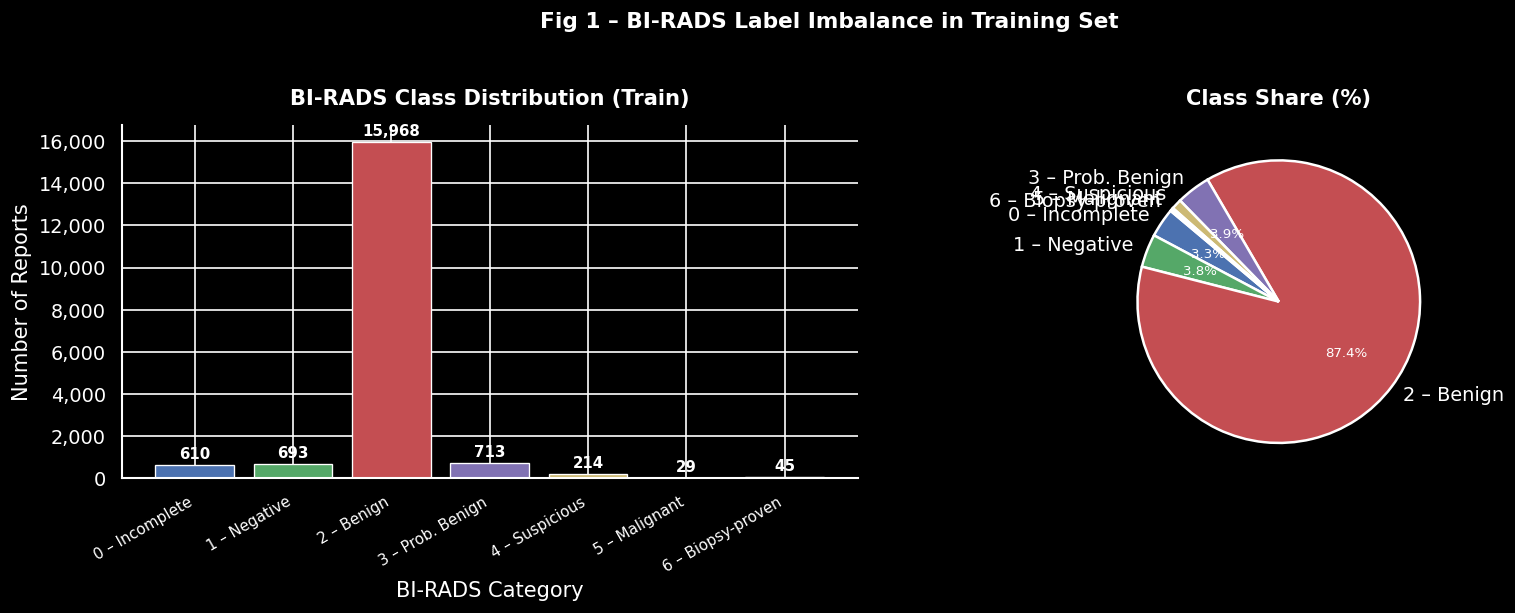

        count   pct
target             
0         610   3.3
1         693   3.8
2       15968  87.4
3         713   3.9
4         214   1.2
5          29   0.2
6          45   0.2


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


plt.style.use("dark_background")

counts = train["target"].value_counts().sort_index()
labels = [BIRADS_LABELS[i] for i in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar chart ───────────────────────────────────────
ax = axes[0]
bars = ax.bar(range(len(labels)), counts.values,
              color=PALETTE[:len(counts)],
              edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts)*0.01,
            f"{val:,}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="white")

ax.set_title("BI-RADS Class Distribution (Train)", fontweight="bold", pad=12)
ax.set_xlabel("BI-RADS Category")
ax.set_ylabel("Number of Reports")


ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Pie chart ───────────────────────────────────────
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=labels,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    colors=PALETTE[:len(counts)],
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)

for t in texts:
    t.set_color("white")

for t in autotexts:
    t.set_fontsize(8)
    t.set_color("white")

ax2.set_title("Class Share (%)", fontweight="bold", pad=12)

# ── Title & layout ─────────────────────────────────
plt.suptitle("Fig 1 – BI-RADS Label Imbalance in Training Set",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("fig1_class_distribution_dark.png",
            bbox_inches="tight", facecolor="black")

plt.show()

print(
    counts.rename("count")
    .to_frame()
    .assign(pct=lambda df: (df["count"]/df["count"].sum()*100).round(1))
)

## 2.2 Report Length Analysis

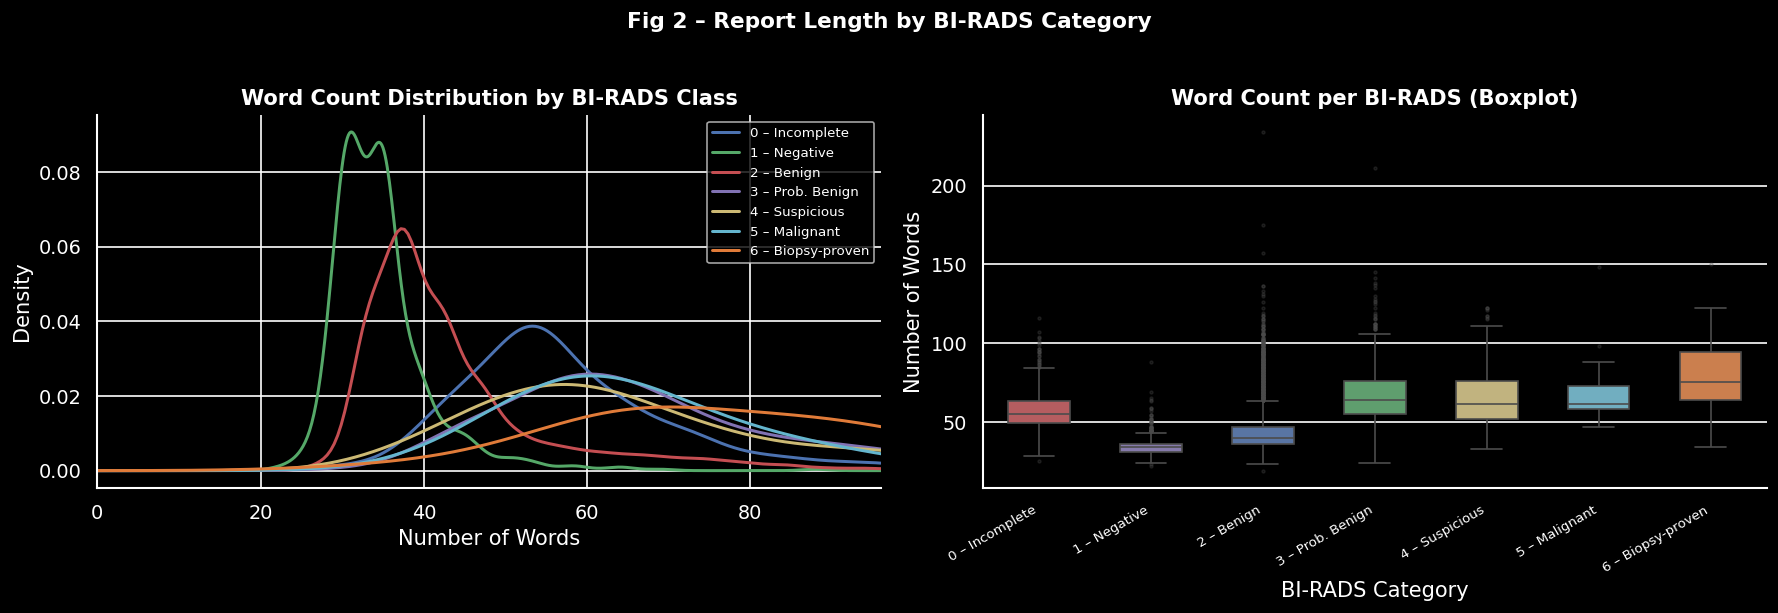


Word count statistics:
          count  mean   std   min   25%   50%   75%    max
target                                                    
0         610.0  57.3  13.2  25.0  49.0  55.0  63.0  116.0
1         693.0  34.7   6.1  22.0  31.0  34.0  36.0   88.0
2       15968.0  43.4  12.4  19.0  36.0  40.0  47.0  234.0
3         713.0  67.6  19.6  24.0  55.0  64.0  76.0  211.0
4         214.0  66.0  20.2  33.0  52.0  61.0  76.0  122.0
5          29.0  67.8  19.8  47.0  58.0  61.0  73.0  148.0
6          45.0  79.9  22.6  34.0  64.0  75.0  94.0  150.0


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")

# ── Feature creation ───────────────────────────────
train["n_chars"] = train["report"].str.len()
train["n_words"] = train["report"].str.split().str.len()
test["n_chars"]  = test["report"].str.len()
test["n_words"]  = test["report"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── KDE plot ──────────────────────────────────────
ax = axes[0]
for cat, color in zip(sorted(train["target"].unique()), PALETTE):
    subset = train[train["target"] == cat]["n_words"]
    subset.plot.kde(ax=ax, label=BIRADS_LABELS[cat],
                    color=color, linewidth=1.8)

ax.set_xlim(0, train["n_words"].quantile(0.99))
ax.set_title("Word Count Distribution by BI-RADS Class", fontweight="bold")
ax.set_xlabel("Number of Words")
ax.set_ylabel("Density")
ax.legend(fontsize=8, loc="upper right")

# ── Boxplot (FIXED) ───────────────────────────────
ax2 = axes[1]
train_plot = train.copy()
train_plot["BI-RADS"] = train_plot["target"].map(BIRADS_LABELS)

order = [BIRADS_LABELS[i] for i in sorted(train["target"].unique())]

sns.boxplot(
    data=train_plot,
    x="BI-RADS",
    y="n_words",
    hue="BI-RADS",              
    order=order,
    palette=PALETTE[:len(order)],
    width=0.55,
    flierprops=dict(marker=".", markersize=3, alpha=0.4),
    legend=False,              # remove duplicate legend
    ax=ax2
)

ax2.set_title("Word Count per BI-RADS (Boxplot)", fontweight="bold")
ax2.set_xlabel("BI-RADS Category")
ax2.set_ylabel("Number of Words")

ax2.set_xticks(range(len(order)))
ax2.set_xticklabels(order, rotation=30, ha="right", fontsize=8)

# ── Title & layout ───────────────────────────────
plt.suptitle("Fig 2 – Report Length by BI-RADS Category",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("fig2_report_length_dark.png",
            bbox_inches="tight", facecolor="black")

plt.show()

# ── Stats ────────────────────────────────────────
print("\nWord count statistics:")
print(train.groupby("target")["n_words"].describe().round(1))

## 2.3 Top Keywords per BI-RADS Class

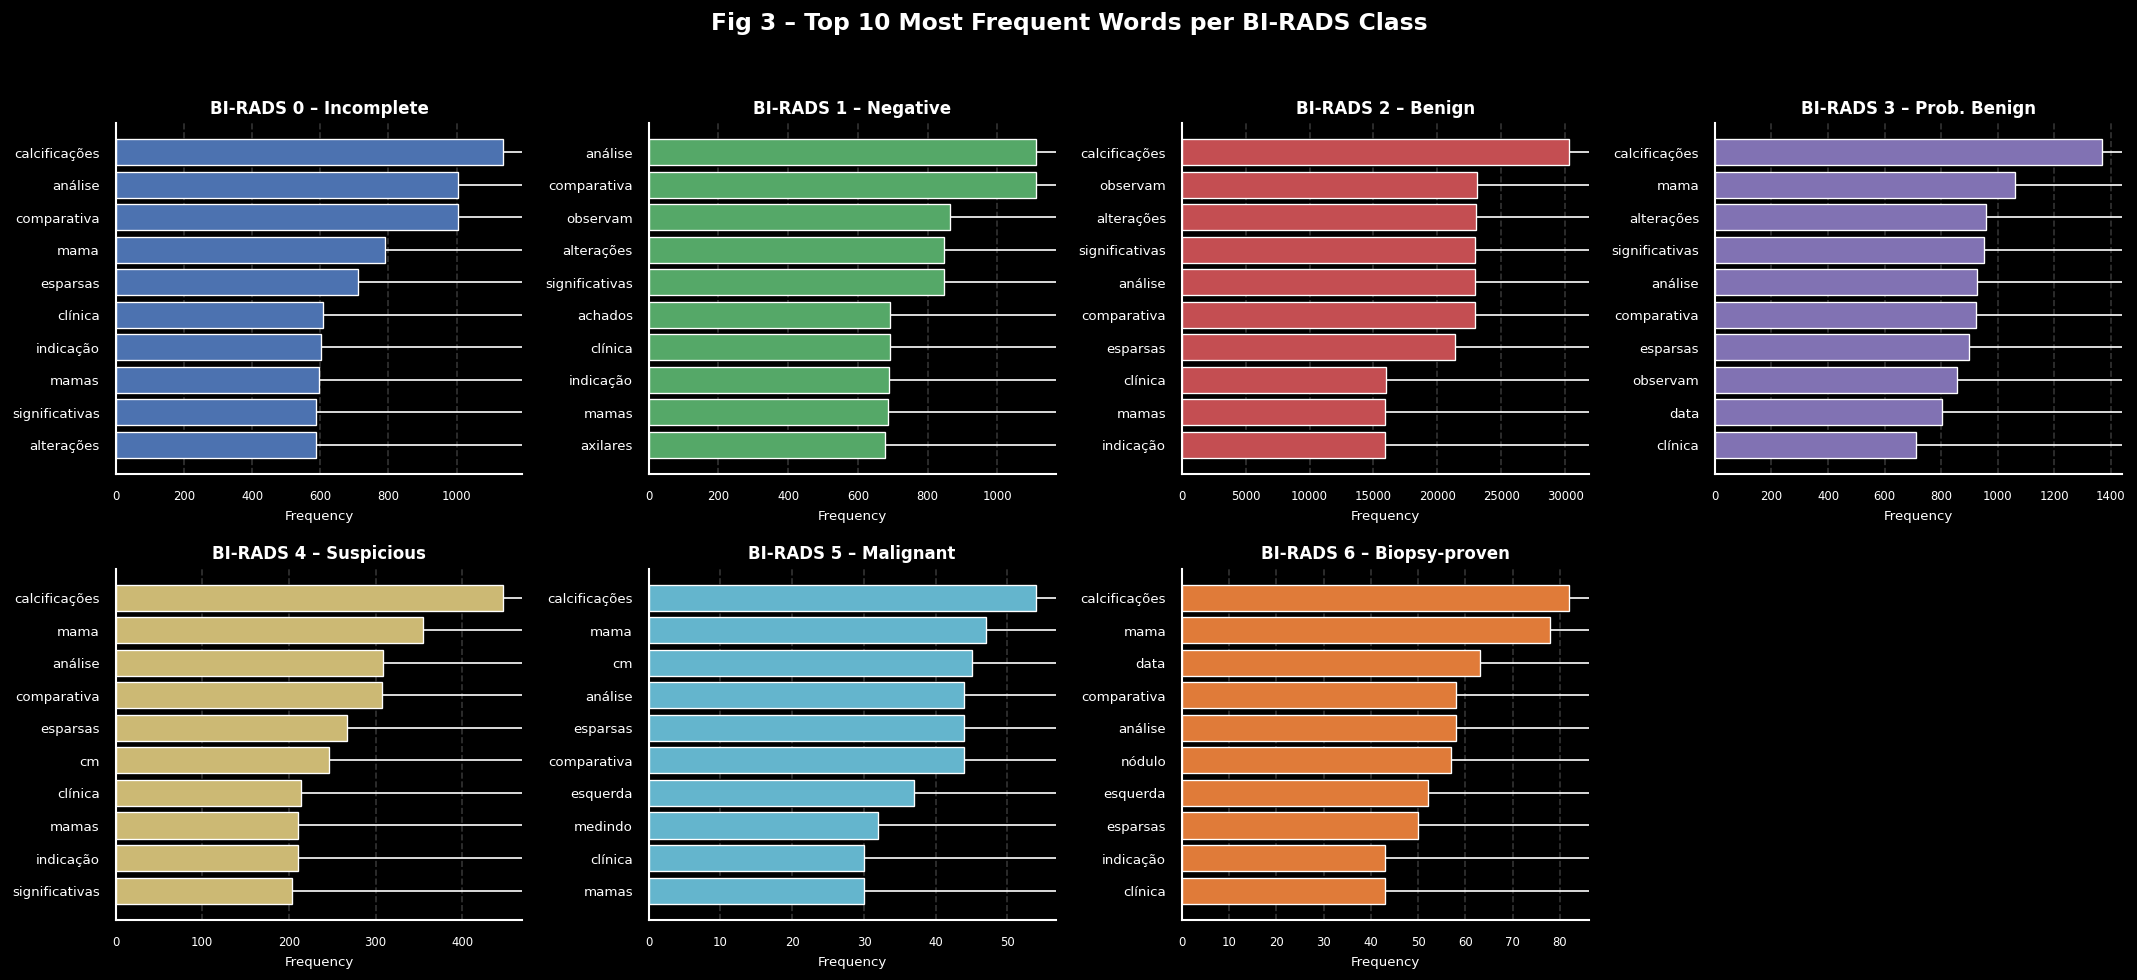

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Dark theme
plt.style.use("dark_background")

STOPWORDS_PT = [
    "de", "a", "o", "e", "do", "da", "em", "um", "uma", "os", "as",
    "no", "na", "para", "com", "por", "se", "que", "ao", "dos", "das",
    "ou", "não", "são", "ser", "foi", "este", "esta", "pelo", "pela",
    "mais", "mas", "its", "the", "of", "and", "to", "in", "is", "at"
]

TOP_N = 10
classes = sorted(train["target"].unique())

ncols = 4
nrows = (len(classes) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

# Vectorizer
vec = CountVectorizer(
    stop_words=STOPWORDS_PT,
    max_features=5000,
    ngram_range=(1, 1),
    min_df=2
)

vec.fit(train["report"].str.lower())
vocab = np.array(vec.get_feature_names_out())

for i, cls in enumerate(classes):
    ax = axes[i]

    subset_text = train[train["target"] == cls]["report"].str.lower()
    X_cls = vec.transform(subset_text)

    freq = np.asarray(X_cls.sum(axis=0)).flatten()
    top_idx = freq.argsort()[-TOP_N:][::-1]

    top_words = vocab[top_idx]
    top_freqs = freq[top_idx]

    color = PALETTE[i % len(PALETTE)]

    ax.barh(
        top_words[::-1],
        top_freqs[::-1],
        color=color,
        edgecolor="white",
        linewidth=0.8
    )

    # Styling
    ax.set_title(f"BI-RADS {BIRADS_LABELS[cls]}",
                 fontweight="bold", fontsize=10, color="white")

    ax.set_xlabel("Frequency", fontsize=8, color="white")

    ax.tick_params(axis="y", labelsize=8, colors="white")
    ax.tick_params(axis="x", labelsize=7, colors="white")

    # Subtle grid for readability
    ax.grid(axis="x", linestyle="--", alpha=0.2)

# Hide unused axes
for j in range(len(classes), len(axes)):
    axes[j].set_visible(False)

# Title
plt.suptitle(
    "Fig 3 – Top 10 Most Frequent Words per BI-RADS Class",
    fontsize=14,
    fontweight="bold",
    y=1.02,
    color="white"
)

plt.tight_layout()

# Save with black background
plt.savefig(
    "fig3_top_keywords_dark.png",
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

***

# 3. Preprocessing

In [7]:
_whitespace_re = re.compile(r"[ \t]+")
_newlines_re = re.compile(r"\n{2,}")

def clean_text(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = s.replace("\r\n", "\n").replace("\r", "\n")
    s = _whitespace_re.sub(" ", s)
    s = _newlines_re.sub("\n", s)
    return s

In [8]:
# Stable hash for GroupKFold (prevents leakage from duplicates)
def stable_hash(s: str) -> str:
    return hashlib.md5(s.encode("utf-8")).hexdigest()

train["text"] = train["report"].apply(clean_text)
test["text"]  = test["report"].apply(clean_text)

train["group"] = train["text"].apply(stable_hash)

# Quick check
print("Unique groups:", train["group"].nunique(), "out of", len(train))
train[["ID", "text", "target", "group"]].head()

Unique groups: 9100 out of 18272


,ID,text,target,group
0,Acc1,indicação clínica:\n rastreamento.\nachados:\n...,2,11d662673e595efff0bb7c7aa93a9f9a
1,Acc3,indicação clínica:\n rastreamento.\nachados:\n...,2,a5c7532aca641cd95ba38fae28d4bb19
2,Acc5,indicação clínica:\n rastreamento.\nachados:\n...,2,19dad66c3058df7695d55c5126dfaab2
3,Acc6,indicação clínica:\n reavaliação de alteração ...,2,16a0e343abe848aab3babdf9dc7f42b7
4,Acc7,indicação clínica:\n reavaliação de alteração ...,2,dde5ef2dd1fb90569f4d1f644cfced93


***

# 4. CV Baseline

In [9]:
# CV baseline: TF-IDF + LinearSVC (macro F1) with GroupKFold

X_text = train["text"].values
y = train["target"].astype(int).values
groups = train["group"].values

word_tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    max_features=80000,
)

# Word- and Character-Level N-grams
tfidf = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf),
])

# LinearSVC is strong for high-dimensional sparse TF-IDF
# class_weight='balanced' is critical because macro F1 + heavy imbalance
base_clf = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)

gkf = GroupKFold(n_splits=N_SPLITS)

fold_scores = []
oof_pred = np.empty(len(train), dtype=int)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_text, y, groups=groups), 1):
    X_tr = tfidf.fit_transform(X_text[tr_idx])
    X_va = tfidf.transform(X_text[va_idx])

    base_clf.fit(X_tr, y[tr_idx])
    pred_va = base_clf.predict(X_va)

    oof_pred[va_idx] = pred_va
    score = f1_score(y[va_idx], pred_va, average="macro")
    fold_scores.append(score)

    print(f"Fold {fold}/{N_SPLITS} | macro F1: {score:.5f}")

cv_mean = float(np.mean(fold_scores))
cv_std  = float(np.std(fold_scores))
oof_score = f1_score(y, oof_pred, average="macro")

print("\nCV mean:", f"{cv_mean:.5f}", "| CV std:", f"{cv_std:.5f}")
print("OOF macro F1:", f"{oof_score:.5f}")

Fold 1/5 | macro F1: 0.69650
Fold 2/5 | macro F1: 0.72773
Fold 3/5 | macro F1: 0.74589
Fold 4/5 | macro F1: 0.75394
Fold 5/5 | macro F1: 0.77790

CV mean: 0.74039 | CV std: 0.02723
OOF macro F1: 0.74243


## 4.1 CV Fold Scores

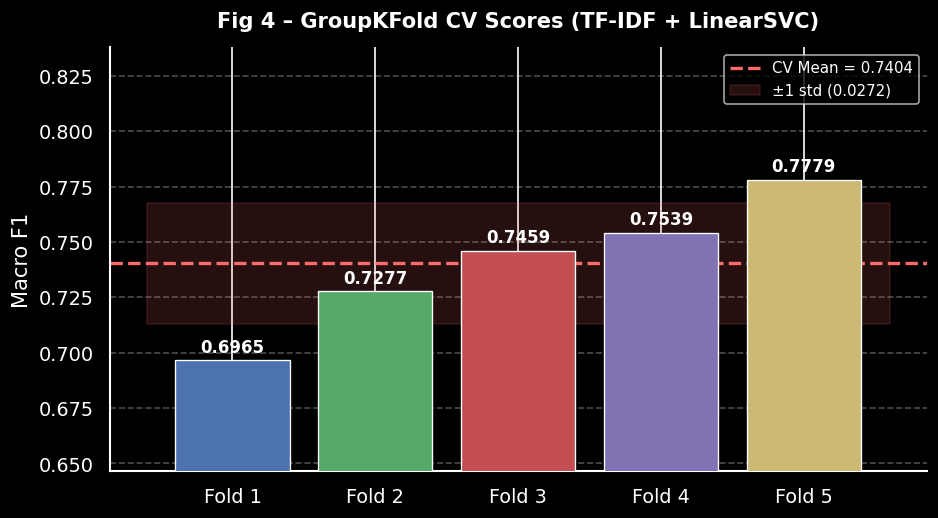

In [10]:
import matplotlib.pyplot as plt

# Dark theme
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(8, 4.5))

fold_nums = list(range(1, N_SPLITS + 1))

bars = ax.bar(
    fold_nums,
    fold_scores,
    color=PALETTE[:N_SPLITS],
    edgecolor="white",
    linewidth=0.8,
    zorder=3
)

# Annotate bars
for bar, score in zip(bars, fold_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

# Mean line
ax.axhline(
    cv_mean,
    color="#FF6B6B",
    linewidth=2,
    linestyle="--",
    label=f"CV Mean = {cv_mean:.4f}"
)

# Std shading
ax.fill_between(
    [0.4, N_SPLITS + 0.6],
    cv_mean - cv_std,
    cv_mean + cv_std,
    color="#FF6B6B",
    alpha=0.15,
    label=f"±1 std ({cv_std:.4f})"
)

# Axes styling
ax.set_xticks(fold_nums)
ax.set_xticklabels([f"Fold {f}" for f in fold_nums], color="white")

ax.set_ylim(
    max(0, min(fold_scores) - 0.05),
    min(1, max(fold_scores) + 0.06)
)

ax.set_ylabel("Macro F1", color="white")

ax.set_title(
    "Fig 4 – GroupKFold CV Scores (TF-IDF + LinearSVC)",
    fontweight="bold",
    pad=12,
    color="white"
)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

# Legend
legend = ax.legend(fontsize=9)
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()

# Save with black background
plt.savefig(
    "fig4_cv_scores_dark.png",
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 4.2 Out-of-Fold Confusion Matrix

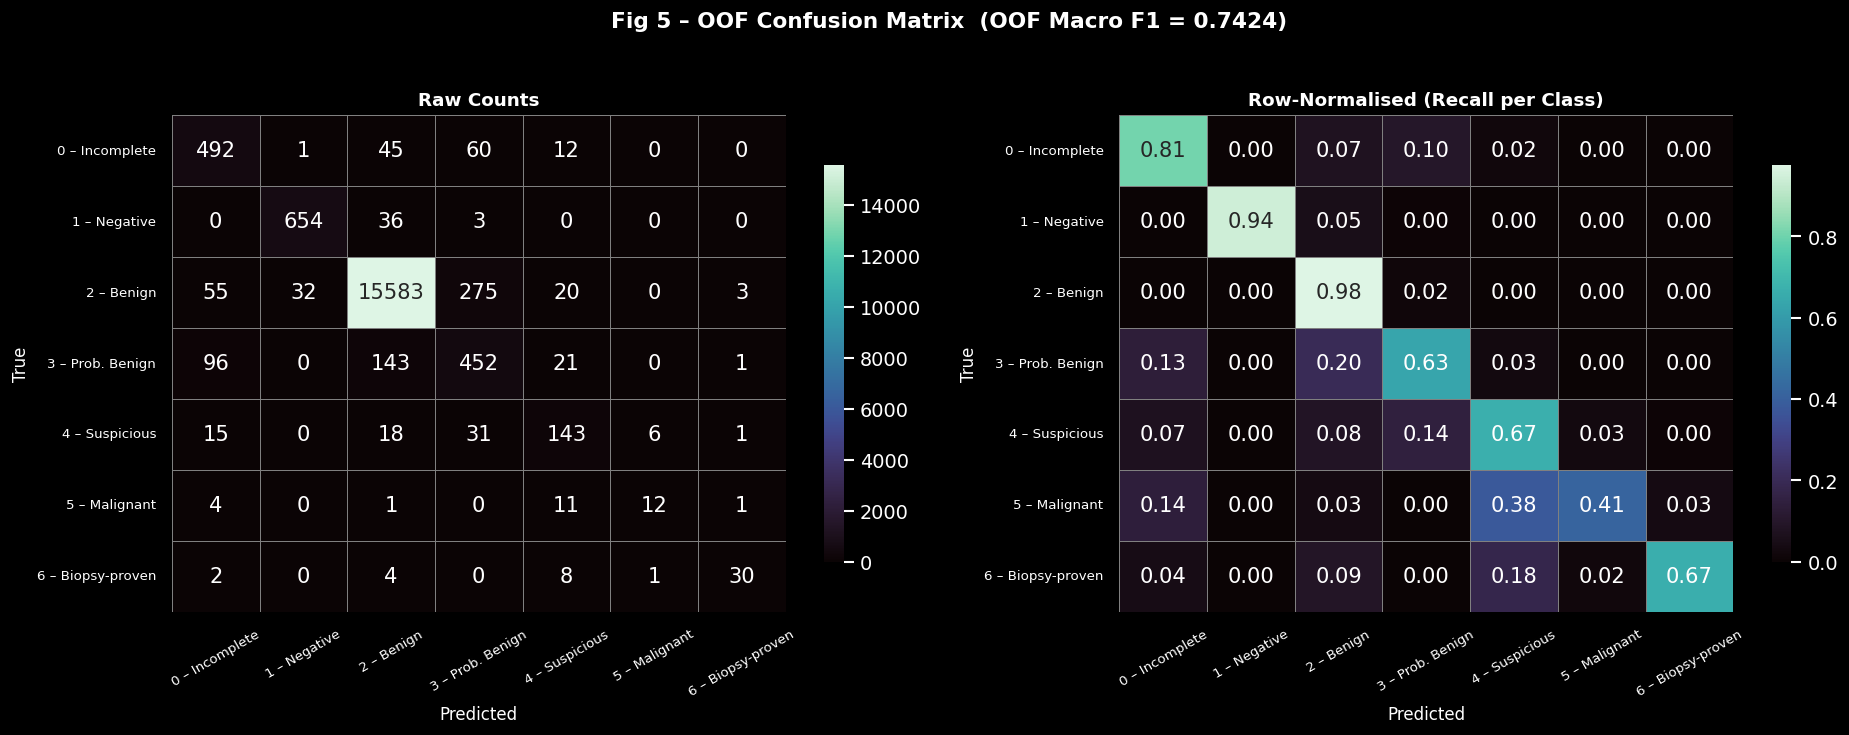


Classification Report (OOF):
                   precision    recall  f1-score   support

   0 – Incomplete     0.7410    0.8066    0.7724       610
     1 – Negative     0.9520    0.9437    0.9478       693
       2 – Benign     0.9844    0.9759    0.9801     15968
 3 – Prob. Benign     0.5505    0.6339    0.5893       713
   4 – Suspicious     0.6651    0.6682    0.6667       214
    5 – Malignant     0.6316    0.4138    0.5000        29
6 – Biopsy-proven     0.8333    0.6667    0.7407        45

         accuracy                         0.9504     18272
        macro avg     0.7654    0.7298    0.7424     18272
     weighted avg     0.9534    0.9504    0.9517     18272



In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Dark theme
plt.style.use("dark_background")

cm = confusion_matrix(y, oof_pred, labels=sorted(np.unique(y)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

class_labels = [BIRADS_LABELS[i] for i in sorted(np.unique(y))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plots = [
    (cm, "d", "Raw Counts"),
    (cm_norm, ".2f", "Row-Normalised (Recall per Class)")
]

for ax_i, (mat, fmt, title) in enumerate(plots):
    ax = axes[ax_i]

    sns.heatmap(
        mat,
        annot=True,
        fmt=fmt,
        xticklabels=class_labels,
        yticklabels=class_labels,
        cmap="mako",              
        linewidths=0.6,
        linecolor="gray",
        cbar_kws={"shrink": 0.8},
        ax=ax
    )

    # Titles & labels
    ax.set_title(title, fontweight="bold", fontsize=11, color="white")
    ax.set_xlabel("Predicted", fontsize=10, color="white")
    ax.set_ylabel("True", fontsize=10, color="white")

    # Tick styling
    ax.tick_params(axis="x", rotation=30, labelsize=8, colors="white")
    ax.tick_params(axis="y", rotation=0, labelsize=8, colors="white")

# Main title
plt.suptitle(
    f"Fig 5 – OOF Confusion Matrix  (OOF Macro F1 = {oof_score:.4f})",
    fontsize=13,
    fontweight="bold",
    y=1.02,
    color="white"
)

plt.tight_layout()

# Save with black background
plt.savefig(
    "fig5_confusion_matrix_dark.png",
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# Report
print("\nClassification Report (OOF):")
print(classification_report(
    y, oof_pred,
    target_names=class_labels,
    digits=4
))

## 4.3 Per-Class F1 Score

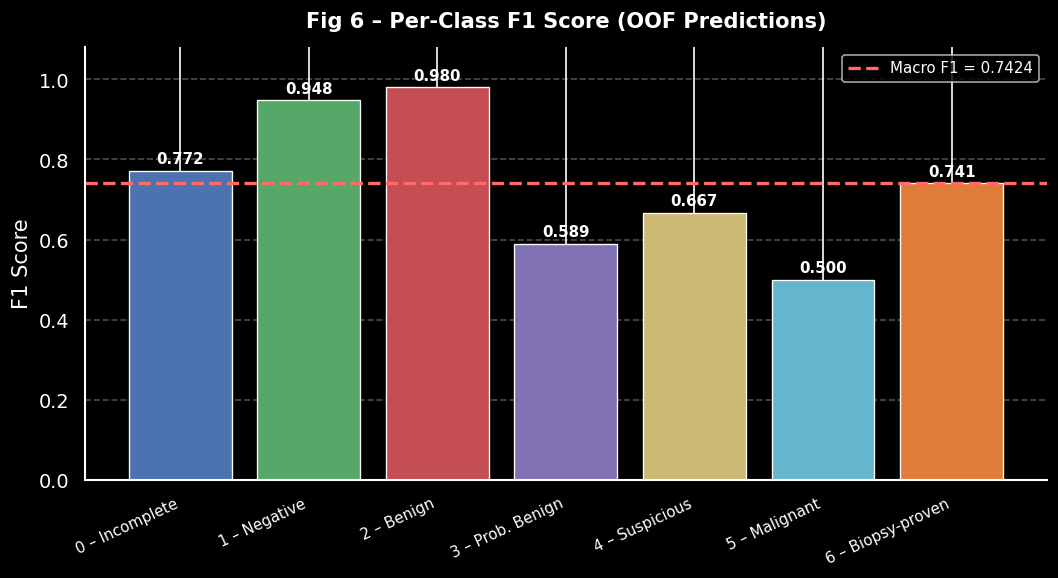

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score as f1

# Dark theme
plt.style.use("dark_background")

# ── Compute per-class F1 ─────────────────────────
labels_sorted = sorted(np.unique(y))
per_class_f1 = f1(y, oof_pred, average=None, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(9, 5))

# Use numeric positions to avoid tick warning
x_pos = range(len(class_labels))

bars = ax.bar(
    x_pos,
    per_class_f1,
    color=PALETTE[:len(class_labels)],
    edgecolor="white",
    linewidth=0.8
)

# Annotate bars
for bar, val in zip(bars, per_class_f1):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="white"
    )

# Mean line
ax.axhline(
    oof_score,
    color="#FF6B6B",
    linewidth=2,
    linestyle="--",
    label=f"Macro F1 = {oof_score:.4f}"
)

# ✅ FIX: proper ticks before labels
ax.set_xticks(x_pos)
ax.set_xticklabels(class_labels, rotation=25, ha="right", fontsize=9, color="white")

ax.set_ylim(0, 1.08)
ax.set_ylabel("F1 Score", color="white")

ax.set_title(
    "Fig 6 – Per-Class F1 Score (OOF Predictions)",
    fontweight="bold",
    pad=12,
    color="white"
)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Legend styling
legend = ax.legend(fontsize=9)
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()

# Save with black background
plt.savefig(
    "fig6_per_class_f1_dark.png",
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 4.4 Train vs Test Report-Length Comparison

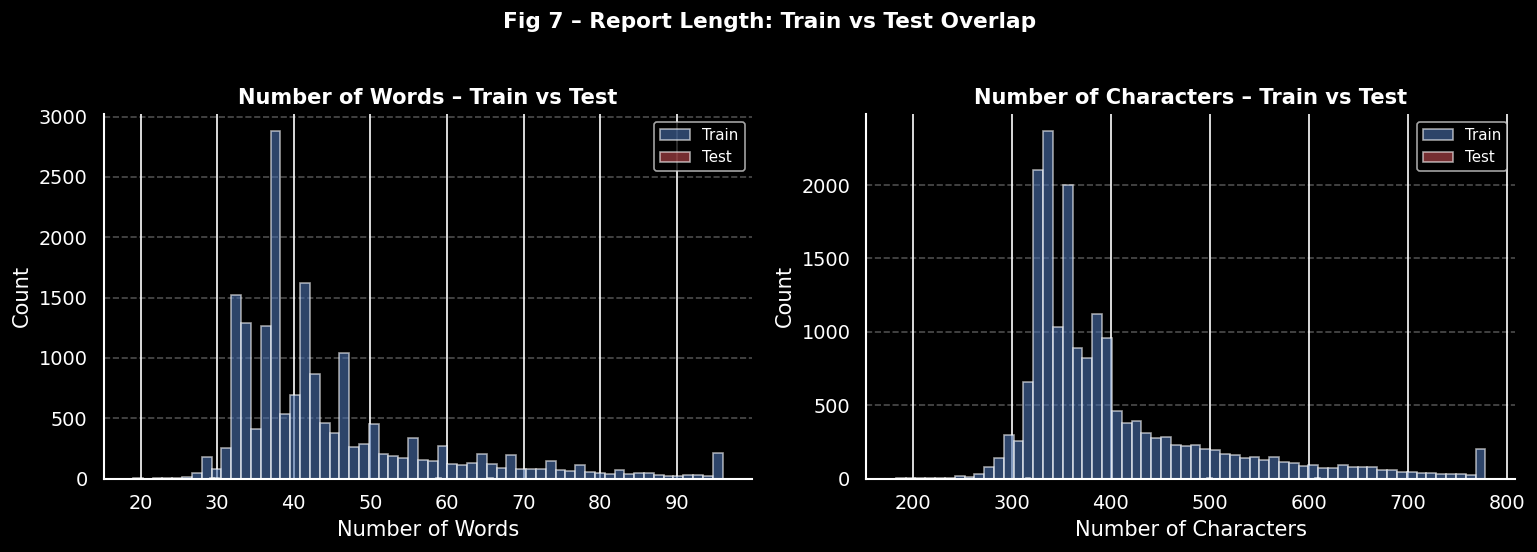

Word count summary:
         Train  Test
count  18272.0   4.0
mean      44.9  46.0
std       14.2  19.3
min       19.0  29.0
25%       36.0  29.8
50%       40.0  44.5
75%       48.0  60.8
max      234.0  66.0


In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Dark theme
plt.style.use("dark_background")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, col, xlabel in zip(
    axes,
    ["n_words", "n_chars"],
    ["Number of Words", "Number of Characters"]
):
    clip = max(train[col].quantile(0.99), test[col].quantile(0.99))

    # Train histogram
    train[col].clip(upper=clip).plot.hist(
        ax=ax,
        bins=60,
        alpha=0.6,
        color=PALETTE[0],
        label="Train",
        edgecolor="white"
    )

    # Test histogram
    test[col].clip(upper=clip).plot.hist(
        ax=ax,
        bins=60,
        alpha=0.6,
        color=PALETTE[2],
        label="Test",
        edgecolor="white"
    )

    ax.set_xlabel(xlabel, color="white")
    ax.set_ylabel("Count", color="white")

    ax.set_title(f"{xlabel} – Train vs Test",
                 fontweight="bold", color="white")

    # Grid
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # Legend styling
    legend = ax.legend(fontsize=9)
    for text in legend.get_texts():
        text.set_color("white")

    # Tick colors
    ax.tick_params(axis="x", colors="white")
    ax.tick_params(axis="y", colors="white")

# Title
plt.suptitle(
    "Fig 7 – Report Length: Train vs Test Overlap",
    fontsize=13,
    fontweight="bold",
    y=1.02,
    color="white"
)

plt.tight_layout()

# Save with black background
plt.savefig(
    "fig7_train_vs_test_length_dark.png",
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# Summary
print("Word count summary:")
print(pd.DataFrame({
    "Train": train["n_words"].describe(),
    "Test":  test["n_words"].describe()
}).round(1))

***

# 5. Submission

In [14]:
# Load evaluation/test set (exists in code-competition runtime)
if os.path.exists(TEST_PATH):
    test = pd.read_csv(TEST_PATH)
    print("test:", test.shape)
else:
    raise FileNotFoundError(
        f"test.csv not found at {TEST_PATH}. "
        "This is expected in some code competitions during interactive sessions; "
        "it should exist in the evaluation runtime."
    )

assert {"ID", "report", "target"}.issubset(train.columns), train.columns
assert {"ID", "report"}.issubset(test.columns), test.columns

test: (4, 2)


In [15]:
test["text"] = test["report"].apply(clean_text)

In [16]:
# Train final model on full data + create submission.csv

# Refit vectorizers on training data
X_train_full = tfidf.fit_transform(train["text"])
y_full = train["target"].astype(int).values

# Train final classifier
final_clf = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=10000,
)

final_clf.fit(X_train_full, y_full)

# Transform hidden test set
X_test = tfidf.transform(test["text"])

# Predict
test_pred = final_clf.predict(X_test).astype(int)

# Build submission file
submission = pd.DataFrame({
    "ID": test["ID"],
    "target": test_pred
})

# Save
submission.to_csv("submission.csv", index=False)

print("submission.csv saved")
submission.head()

submission.csv saved


,ID,target
0,Acc0,6
1,Acc2,2
2,Acc4,2
3,Acc10,2


## 5.1 Predicted Class Distribution

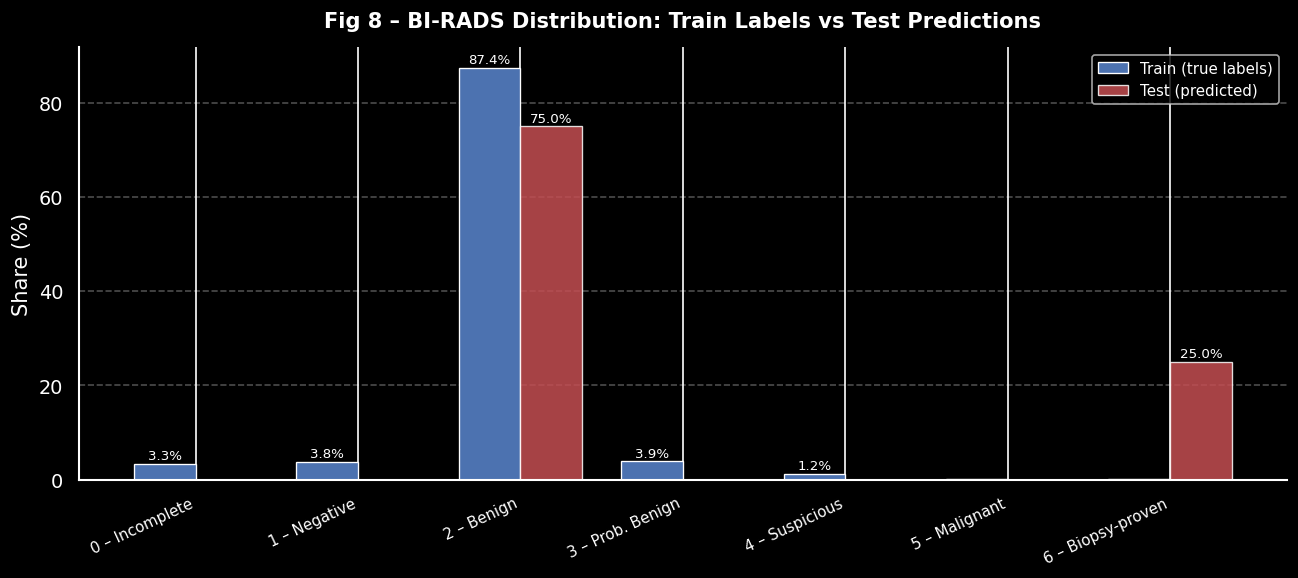

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Dark theme
plt.style.use("dark_background")

# ── Distribution prep ────────────────────────────
train_dist = train["target"].value_counts().sort_index()
pred_dist  = pd.Series(test_pred).value_counts().sort_index()

all_classes = sorted(set(train_dist.index) | set(pred_dist.index))

train_pct = train_dist.reindex(all_classes, fill_value=0) / len(train) * 100
pred_pct  = pred_dist.reindex(all_classes, fill_value=0) / len(test_pred) * 100

x = np.arange(len(all_classes))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(
    x - width/2,
    train_pct,
    width,
    label="Train (true labels)",
    color=PALETTE[0],
    edgecolor="white",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    pred_pct,
    width,
    label="Test (predicted)",
    color=PALETTE[2],
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85
)

# Annotate bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.5:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.3,
                f"{h:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
                color="white"
            )

# Axes styling
ax.set_xticks(x)
ax.set_xticklabels(
    [BIRADS_LABELS[c] for c in all_classes],
    rotation=25,
    ha="right",
    fontsize=9,
    color="white"
)

ax.set_ylabel("Share (%)", color="white")

ax.set_title(
    "Fig 8 – BI-RADS Distribution: Train Labels vs Test Predictions",
    fontweight="bold",
    pad=12,
    color="white"
)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Legend styling
legend = ax.legend(fontsize=9)
for text in legend.get_texts():
    text.set_color("white")

# Tick colors
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

plt.tight_layout()

# Save with black background
plt.savefig(
    "fig8_prediction_distribution_dark.png",
    bbox_inches="tight",
    facecolor="black"
)

plt.show()